In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv(r"C:\Users\asmis\OneDrive\Desktop\foodbridge\data\food_master_dataset.csv")

df.head()

,date,city,district,outlet_type,total_prepared_kg,total_sold_kg,surplus_kg,footfall_count,rainfall_mm,temperature_c,...,unemployment_rate,malnutrition_rate,literacy_rate,population_density,rainfall_category,temperature_category,surplus_category,feedback_source,feedback_text,sentiment_label
0,2024-04-12,Chennai,Mumbai Suburban,restaurant,234.27,178.91,55.36,936,33.819924,22.980879,...,9.281988,23.345097,71.159051,13857.50378,medium,cool,medium,logistics_team,Food supply was slightly different than expect...,neutral
1,2025-03-11,Chennai,Hyderabad,restaurant,216.43,169.38,47.05,611,57.927890,27.431975,...,5.543214,31.585074,57.331012,27642.76583,medium,moderate,medium,restaurant_staff,Coordination with volunteers worked great and ...,positive
2,2024-09-27,Chennai,Chennai,restaurant,222.05,135.79,86.26,1004,19.304584,25.671839,...,2.607615,37.821608,74.279447,22704.52683,low,moderate,medium,restaurant_staff,Food supply was slightly different than expect...,neutral
3,2024-04-16,Hyderabad,Chennai,restaurant,351.51,329.97,21.54,787,10.248639,27.042423,...,5.059368,15.320457,74.441768,19956.61007,low,moderate,low,logistics_team,Community support was excellent and food reach...,positive
4,2024-03-12,Bangalore,Hyderabad,supermarket,406.52,355.98,50.54,805,23.895929,24.664987,...,13.216180,8.737902,85.915223,14806.84788,medium,cool,medium,volunteer,Shelter operations were routine with no major ...,neutral


In [5]:
df["date"] = pd.to_datetime(df["date"], format="mixed", dayfirst=True)

df = df.sort_values("date")

In [6]:
ts = df.set_index("date").resample("W")["surplus_kg"].sum()

print(ts.head())

date
2024-01-07    6329.09
2024-01-14    8481.03
2024-01-21    6570.81
2024-01-28    6909.11
2024-02-04    5169.16
Freq: W-SUN, Name: surplus_kg, dtype: float64


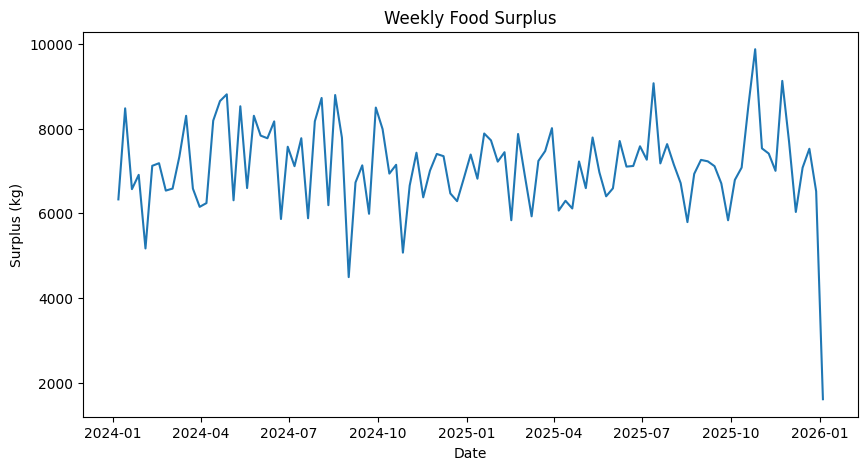

In [7]:
plt.figure(figsize=(10,5))

plt.plot(ts)

plt.title("Weekly Food Surplus")

plt.xlabel("Date")

plt.ylabel("Surplus (kg)")

plt.show()

In [8]:
print(ts.describe())

count     105.000000
mean     7098.971905
std      1063.366307
min      1605.930000
25%      6570.810000
50%      7122.690000
75%      7709.080000
max      9878.200000
Name: surplus_kg, dtype: float64


In [9]:
ts_log = np.log1p(ts)

In [10]:
train_size = int(len(ts_log) * 0.8)

train = ts_log[:train_size]

test = ts_log[train_size:]

In [11]:
model = ARIMA(train, order=(2,1,2))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             surplus_kg   No. Observations:                   84
Model:                 ARIMA(2, 1, 2)   Log Likelihood                  51.721
Date:                Tue, 17 Mar 2026   AIC                            -93.442
Time:                        19:41:41   BIC                            -81.347
Sample:                    01-07-2024   HQIC                           -88.583
                         - 08-10-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9568      0.137     -6.966      0.000      -1.226      -0.688
ar.L2         -0.1242      0.127     -0.980      0.327      -0.372       0.124
ma.L1      -2.343e-05     81.069  -2.89e-07      1.0

c:\Users\asmis\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
forecast_log = model_fit.forecast(steps=len(test))

In [13]:
forecast = np.expm1(forecast_log)

actual = np.expm1(test)

In [14]:
rmse = np.sqrt(mean_squared_error(actual, forecast))

print("Forecast RMSE:", rmse)

Forecast RMSE: 1542.697037771053


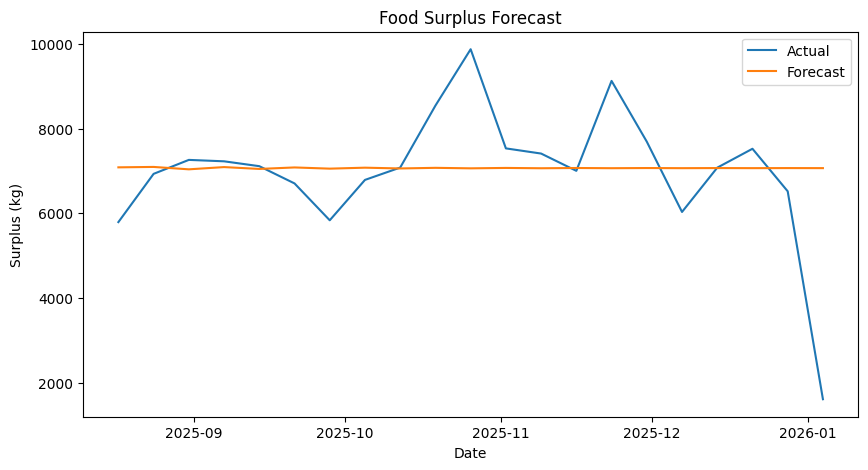

In [15]:
plt.figure(figsize=(10,5))

plt.plot(actual.index, actual, label="Actual")

plt.plot(actual.index, forecast, label="Forecast")

plt.legend()

plt.title("Food Surplus Forecast")

plt.xlabel("Date")

plt.ylabel("Surplus (kg)")

plt.show()